### Tensor Implementation Details

In [1]:
import torch

In [2]:
x = torch.arange(12, dtype=torch.float32)
print(f"Original Tensor x: {x}")

Original Tensor x: tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])


In [6]:
print(f"Storage elements: {x.storage().tolist()}")
print(f"Storage type: {x.storage().dtype}")
print(f"Storage size: {len(x.storage())}")

Storage elements: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0]
Storage type: torch.float32
Storage size: 12


In [7]:
y = x.view(3, 4)
print(f"\nReshaped tensor y:\n{y}")


Reshaped tensor y:
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])


In [9]:
print(f"Does y share storage with x?: {x.storage().data_ptr() == x.storage().data_ptr()}")

Does y share storage with x?: True


In [10]:
y[0, 0] = 99.0
print(f"\nModified y:\n{y}")
print(f"Original x after modifying y: {x}")


Modified y:
tensor([[99.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
Original x after modifying y: tensor([99.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])


In [11]:
t = torch.arange(12, dtype=torch.float32).view(3, 4)
print(f"Tensor t: \n{t}")
print(f"Shape: {t.shape}")
print(f"Stride: {t.stride()}")

Tensor t: 
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
Shape: torch.Size([3, 4])
Stride: (4, 1)


In [12]:
print(f"Is t contiguous ? {t.is_contiguous()}")

Is t contiguous ? True


In [13]:
t_transposed = t.t()
print(f"\nTransposed tensor t_transposed:\n{t_transposed}")
print(f"Shape: {t_transposed.shape}")
print(f"Stride: {t_transposed.stride()}")
print(f"Is t_transposed contiguous? {t_transposed.is_contiguous()}")
print(f"Does t_transposed share storage with t? {t_transposed.storage().data_ptr() == t.storage().data_ptr()}")


Transposed tensor t_transposed:
tensor([[ 0.,  4.,  8.],
        [ 1.,  5.,  9.],
        [ 2.,  6., 10.],
        [ 3.,  7., 11.]])
Shape: torch.Size([4, 3])
Stride: (1, 4)
Is t_transposed contiguous? False
Does t_transposed share storage with t? True


### Understanding the Computational Graph

In [15]:
a = torch.tensor([2.0, 3.0], requires_grad=True)

# Operation 1: Mult by 3
b = a * 3

# Operation 2: Calculate the mean
c  = b.mean()

print(f"Tensor a: requires_grad={a.requires_grad}, grad_fn={a.grad_fn}")
print(f"Tensor b: requires_grad={b.requires_grad}, grad_fn={b.grad_fn}")
print(f"Tensor c: requires_grad={c.requires_grad}, grad_fn={c.grad_fn}")

Tensor a: requires_grad=True, grad_fn=None
Tensor b: requires_grad=True, grad_fn=<MulBackward0 object at 0x7fddda226890>
Tensor c: requires_grad=True, grad_fn=<MeanBackward0 object at 0x7fddda225390>


### Autograd Mechanics

In [16]:
w = torch.randn(5, 3, requires_grad=True)
x = torch.randn(1, 5)

y = x @ w
z = y.mean()

z.backward()
print(w.grad.shape)

torch.Size([5, 3])


### Custom Autograd Functions: Forward and Backward

In [18]:
from torch.autograd import Function


class MyLinearFunction(Function):
    @staticmethod
    def forward(ctx, x, w, b=None):
        output = x.mm(w.t())
        if b is not None:
            o += b.unsqueeze(0).expand_as(o)
        ctx.save_for_backward(x, w, b)
        return o

    @staticmethod
    def backward(ctx, grad_output):
        pass


In [21]:
w = torch.randn(5, 3, requires_grad=True)
x = torch.randn(3, 2)
y_true = torch.randn(5, 2)

y_pred = w @ x
loss = torch.nn.functional.mse_loss(y_pred, y_true)

loss.backward()

print(f"Gradient for w:\n{w.grad}")
print(f"Gradient for x:{x.grad}")
print(f"Gradient for y_pred:{y_pred.grad}")

Gradient for w:
tensor([[ 0.1502,  0.3975,  0.1960],
        [ 0.5229,  0.5530,  0.5313],
        [-0.3793,  0.0965, -0.2951],
        [-0.2058,  0.7113, -0.0406],
        [ 0.1121,  0.1922,  0.1273]])
Gradient for x:None
Gradient for y_pred:None


/tmp/ipykernel_67405/3745080546.py:12: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /__w/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:493.)
  print(f"Gradient for y_pred:{y_pred.grad}")


### Visualizing the Computational Graph

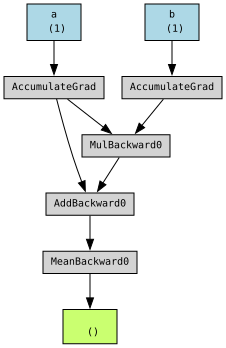

In [24]:
import torchviz

a = torch.tensor([2.0], requires_grad=True)
b = torch.tensor([3.0], requires_grad=True)

c = a * b
d = c + a

L = d.mean()

graph = torchviz.make_dot(L, params={'a': a, 'b': b})
display(graph)

In [25]:
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter

# Define a simple model again
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(5, 3)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(3, 1)
    def forward(self, x):
        return self.layer2(self.relu(self.layer1(x)))

model = SimpleNet()
dummy_input = torch.randn(1, 5) # Provide a sample input

# Create a SummaryWriter instance (logs to ./runs/ by default)
writer = SummaryWriter('runs/graph_demo')

# Add the graph to TensorBoard
# The writer requires the model and a sample input tensor
writer.add_graph(model, dummy_input)
writer.close()

I0000 00:00:1788872453.707671   67405 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
